In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, glob, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from scipy.signal import savgol_filter
from scipy.stats import spearmanr
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)

Running on: cuda


In [ ]:
CFG = {
    'csv_dir': '/content/drive/MyDrive/Physiotherapy_Thesis/outputs_24_joints',
    'score_path':    '/content/drive/MyDrive/Physiotherapy_Thesis/Master_ClinicalAssessment.xlsx',
    'score_type':    'TS',            # 'TS' | 'PO' | 'CF'
    'exercises':     [1, 2, 3, 4, 5],
    'target_frames': 288,
    'n_folds':       5,
    'seed':          42,
    # augmentation (sadece train fold)
    'augment':       True,
    'noise_std':     0.01,
    'scale_range':   (0.95, 1.05),
    'warp_range':    (0.90, 1.10),
    # training
    'epochs':        150,
    'patience':      20,
    'batch_size':    16,
    'lr':            1e-3,
    'hidden_dim':    64,
    'dropout':       0.3,
    'grad_clip':     1.0,
    'huber_delta':   5.0,
}

In [ ]:
class SkeletonDataset(Dataset):
    """Tüm dizileri bir kez yükler, işler, bellekte tutar."""
    def __init__(self, csv_dir, score_path, score_type='TS',
                 exercises=(1, 2, 3, 4, 5), target_frames=288):
        self.target_frames = target_frames
        scores_df = pd.read_excel(score_path).set_index('Subject ID')

        files = sorted(glob.glob(os.path.join(csv_dir, '**', '*.csv'), recursive=True))
        files = [f for f in files if 'Master_ClinicalAssessment' not in f]

        self.samples, self.scores = [], []
        self.subject_ids, self.exercise_ids = [], []
        skipped = 0

        for fp in files:
            parts = os.path.basename(fp).split('_')
            try:
                subject_id = f"{parts[0]}_{parts[1]}"
                ex_number = int(parts[2].replace('Es', ''))
            except (IndexError, ValueError):
                skipped += 1; continue
            if ex_number not in exercises:
                continue
            col = f'clinical {score_type} Ex#{ex_number}'
            try:
                score = scores_df.loc[subject_id, col]
            except KeyError:
                skipped += 1; continue
            if pd.isna(score):
                skipped += 1; continue
            seq = self._preprocess(fp)
            if seq is None:
                skipped += 1; continue
            self.samples.append(seq.astype(np.float32))
            self.scores.append(float(score))
            self.subject_ids.append(subject_id)
            self.exercise_ids.append(ex_number)

        self.scores       = np.array(self.scores, dtype=np.float32)
        self.subject_ids  = np.array(self.subject_ids)
        self.exercise_ids = np.array(self.exercise_ids)
        self.input_dim    = self.samples[0].shape[1] if self.samples else 0
        print(f"Loaded {len(self.samples)} samples "
              f"({len(set(self.subject_ids))} subjects), skipped {skipped}.")
        print(f"Auto-detected input_dim = {self.input_dim}")

    def _preprocess(self, fp):
        df = pd.read_csv(fp)
        if 'timestamp_sec' in df.columns:
            df = df.drop(columns=['timestamp_sec'])
        cols = list(df.columns)                       # kalça indeksini isimden bulmak için

        df = df.interpolate(method='linear', limit_direction='both').fillna(0.0)
        data = df.values
        if data.shape[0] < 2:
            return None

        w = 11 if data.shape[0] > 11 else data.shape[0]
        if w % 2 == 0: w -= 1
        if w > 3:
            data = savgol_filter(data, window_length=w, polyorder=3, axis=0)

        n = data.shape[0]
        reshaped = data.reshape(n, -1, 3)

        # Mid-hip centering — kolon İSMİNE göre (joint sırasından bağımsız, kırılmaz)
        if 'L_Hip_x' in cols and 'R_Hip_x' in cols:
            li = cols.index('L_Hip_x') // 3
            ri = cols.index('R_Hip_x') // 3
            mid_hip = (reshaped[:, li, :] + reshaped[:, ri, :]) / 2.0
            reshaped = reshaped - mid_hip[:, np.newaxis, :]

        max_val = np.max(np.abs(reshaped))
        if max_val > 0:
            reshaped = reshaped / max_val
        data = reshaped.reshape(n, -1)

        if data.shape[0] != self.target_frames:
            idx = np.linspace(0, data.shape[0] - 1, self.target_frames).astype(int)
            data = data[idx]
        return data

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.scores[idx]

In [ ]:
base_ds = SkeletonDataset(
    csv_dir=CFG['csv_dir'], score_path=CFG['score_path'],
    score_type=CFG['score_type'], exercises=CFG['exercises'],
    target_frames=CFG['target_frames'],
)
INPUT_DIM  = base_ds.input_dim
NUM_JOINTS = INPUT_DIM // 3
print("NUM_JOINTS =", NUM_JOINTS)

Loaded 285 samples (57 subjects), skipped 5.
Auto-detected input_dim = 69
NUM_JOINTS = 23


In [ ]:
def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    rho = spearmanr(y_true, y_pred).correlation if len(y_true) > 1 else np.nan
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'R2':   float(r2_score(y_true, y_pred)),
        'Spearman': float(rho),
    }

def summarize(name, fold_metrics):
    row = {'Model': name}
    for k in ['RMSE', 'MAE', 'R2', 'Spearman']:
        vals = np.array([m[k] for m in fold_metrics], dtype=float)
        row[k] = f"{np.nanmean(vals):.3f} ± {np.nanstd(vals):.3f}"
    return row

def per_exercise_spearman(exercise_ids, y_true, y_pred):
    rows = {}
    for ex in sorted(set(exercise_ids.tolist())):
        mask = exercise_ids == ex
        if mask.sum() > 1:
            rows[f'Ex{ex}'] = round(float(spearmanr(y_true[mask], y_pred[mask]).correlation), 3)
    return rows

# Subject-grouped K-Fold — aynı kişi asla iki tarafta birden olmaz
groups = base_ds.subject_ids
y_all  = base_ds.scores
gkf = GroupKFold(n_splits=CFG['n_folds'])
splits = list(gkf.split(np.zeros(len(base_ds)), y_all, groups))

for i, (tr, va) in enumerate(splits, 1):
    overlap = set(groups[tr]) & set(groups[va])
    print(f"Fold {i}: train={len(tr)} val={len(va)} | leakage={len(overlap)}")

Fold 1: train=225 val=60 | leakage=0
Fold 2: train=225 val=60 | leakage=0
Fold 3: train=230 val=55 | leakage=0
Fold 4: train=230 val=55 | leakage=0
Fold 5: train=230 val=55 | leakage=0


In [ ]:
def extract_features(x):
    vel = np.diff(x, axis=0)
    return np.concatenate([
        x.mean(0), x.std(0), x.max(0) - x.min(0),
        np.abs(vel).mean(0), vel.std(0),
    ])

X_feat = np.stack([extract_features(s) for s in base_ds.samples])

classical_models = {
    'Mean Predictor': None,
    'Ridge':          Ridge(alpha=10.0),
    'SVR (RBF)':      SVR(C=10.0, gamma='scale'),
    'RandomForest':   RandomForestRegressor(n_estimators=300, random_state=CFG['seed']),
}

baseline_rows = []
for name, model in classical_models.items():
    fold_metrics = []
    for tr, va in splits:
        if name == 'Mean Predictor':
            pred = np.full(len(va), y_all[tr].mean())
        else:
            scaler = StandardScaler().fit(X_feat[tr])
            model.fit(scaler.transform(X_feat[tr]), y_all[tr])
            pred = model.predict(scaler.transform(X_feat[va]))
        fold_metrics.append(compute_metrics(y_all[va], pred))
    baseline_rows.append(summarize(name, fold_metrics))

print(pd.DataFrame(baseline_rows).to_markdown(index=False))

/tmp/ipykernel_4207/4134573946.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).correlation if len(y_true) > 1 else np.nan
/tmp/ipykernel_4207/4134573946.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).correlation if len(y_true) > 1 else np.nan
/tmp/ipykernel_4207/4134573946.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).correlation if len(y_true) > 1 else np.nan
/tmp/ipykernel_4207/4134573946.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).correlation if len(y_true) > 1 else np.nan
/tmp/ipykernel_4207/4134573946.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).cor

| Model          | RMSE           | MAE           | R2             | Spearman      |
|:---------------|:---------------|:--------------|:---------------|:--------------|
| Mean Predictor | 10.221 ± 1.184 | 8.595 ± 0.929 | -0.082 ± 0.122 | nan ± nan     |
| Ridge          | 9.269 ± 0.733  | 7.364 ± 0.586 | 0.052 ± 0.362  | 0.437 ± 0.211 |
| SVR (RBF)      | 9.074 ± 1.319  | 7.154 ± 0.882 | 0.157 ± 0.059  | 0.443 ± 0.082 |
| RandomForest   | 9.017 ± 0.899  | 7.315 ± 0.635 | 0.143 ± 0.174  | 0.439 ± 0.152 |


In [ ]:
import numpy as np
from torch.utils.data import Dataset

def augment_sequence(x, cfg):
    x = x + np.random.normal(0, cfg['noise_std'], x.shape)
    x = x * np.random.uniform(*cfg['scale_range'])
    T = x.shape[0]
    new_T = max(2, int(round(T * np.random.uniform(*cfg['warp_range']))))
    mid = np.stack([np.interp(np.linspace(0, T - 1, new_T), np.arange(T), x[:, j])
                    for j in range(x.shape[1])], axis=1)
    out = np.stack([np.interp(np.linspace(0, new_T - 1, T), np.arange(new_T), mid[:, j])
                    for j in range(mid.shape[1])], axis=1)
    return out.astype(np.float32)

class FoldView(Dataset):
    def __init__(self, base, indices, augment=False, cfg=None, norm_mean=None, norm_std=None):
        self.base, self.indices = base, list(indices)
        self.augment, self.cfg = augment, cfg
        self.norm_mean, self.norm_std = norm_mean, norm_std
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.base.samples[idx].copy()
        if self.augment:
            x = augment_sequence(x, self.cfg)
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor([self.base.scores[idx]], dtype=torch.float32)
        m = torch.tensor([self.norm_mean[idx]], dtype=torch.float32)
        s = torch.tensor([self.norm_std[idx]],  dtype=torch.float32)
        return x, y, m, s

In [ ]:
class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, num_joints, t_kernel=9, stride=1, residual=True):
        super().__init__()
        self.A = nn.Parameter(torch.eye(num_joints) + 0.01 * torch.randn(num_joints, num_joints))
        self.gcn = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        pad = ((t_kernel - 1) // 2, 0)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_ch), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, (t_kernel, 1), (stride, 1), pad),
            nn.BatchNorm2d(out_ch),
        )
        if not residual:
            self.residual = lambda x: 0
        elif in_ch == out_ch and stride == 1:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, (stride, 1)), nn.BatchNorm2d(out_ch))
        self.relu = nn.ReLU()
    def forward(self, x):  # (B, C, T, V)
        res = self.residual(x)
        x = self.gcn(x)
        x = torch.einsum('bctv,vw->bctw', x, self.A)
        x = self.tcn(x)
        return self.relu(x + res)

class STGCN(nn.Module):
    def __init__(self, in_ch=3, num_joints=12, hidden=64, dropout=0.3, output_dim=1):
        super().__init__()
        self.num_joints, self.in_ch = num_joints, in_ch
        self.data_bn = nn.BatchNorm1d(in_ch * num_joints)
        self.layers = nn.ModuleList([
            STGCNBlock(in_ch,      hidden,     num_joints, residual=False),
            STGCNBlock(hidden,     hidden,     num_joints),
            STGCNBlock(hidden,     hidden * 2, num_joints, stride=2),
            STGCNBlock(hidden * 2, hidden * 2, num_joints),
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, output_dim)
    def forward(self, x):  # (B, T, F)
        B, T, F = x.shape
        x = x.view(B, T, self.num_joints, self.in_ch).permute(0, 3, 1, 2).contiguous()
        B, C, T, V = x.shape
        x = x.permute(0, 1, 3, 2).reshape(B, C * V, T)
        x = self.data_bn(x)
        x = x.reshape(B, C, V, T).permute(0, 1, 3, 2).contiguous()
        for layer in self.layers:
            x = layer(x)
        x = x.mean(dim=[2, 3])
        return self.fc(self.dropout(x))

In [ ]:
def run_fold(train_idx, val_idx, cfg, num_joints):
    set_seed(cfg['seed'])
    ex     = base_ds.exercise_ids
    scores = base_ds.scores

    # Per-exercise train istatistikleri (SADECE train fold)
    ex_mean, ex_std = {}, {}
    for e in np.unique(ex[train_idx]):
        vals = scores[train_idx][ex[train_idx] == e]
        ex_mean[e] = float(vals.mean()); ex_std[e] = float(vals.std() + 1e-8)
    g_mean = float(scores[train_idx].mean()); g_std = float(scores[train_idx].std() + 1e-8)
    norm_mean = np.array([ex_mean.get(e, g_mean) for e in ex], dtype=np.float32)
    norm_std  = np.array([ex_std.get(e, g_std)  for e in ex], dtype=np.float32)

    train_view = FoldView(base_ds, train_idx, augment=cfg['augment'], cfg=cfg,
                          norm_mean=norm_mean, norm_std=norm_std)
    val_view   = FoldView(base_ds, val_idx, augment=False,
                          norm_mean=norm_mean, norm_std=norm_std)
    g = torch.Generator(); g.manual_seed(cfg['seed'])
    train_loader = DataLoader(train_view, batch_size=cfg['batch_size'], shuffle=True,
                              generator=g, drop_last=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_view, batch_size=cfg['batch_size'], shuffle=False,
                              num_workers=2, pin_memory=True)

    model = STGCN(in_ch=3, num_joints=num_joints, hidden=cfg['hidden_dim'], dropout=cfg['dropout']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])
    criterion = nn.HuberLoss(delta=cfg['huber_delta'])

    best_mae, best_state, no_improve = float('inf'), None, 0
    for epoch in range(cfg['epochs']):
        model.train()
        for x, y, m, s in train_loader:
            x = x.to(device)
            y_norm = ((y - m) / s).to(device)          # per-exercise normalize
            optimizer.zero_grad()
            loss = criterion(model(x), y_norm)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            optimizer.step()
        scheduler.step()

        model.eval(); preds, tgts = [], []
        with torch.no_grad():
            for x, y, m, s in val_loader:
                p = model(x.to(device)).cpu()
                preds.extend((p * s + m).numpy().ravel())   # per-exercise denormalize
                tgts.extend(y.numpy().ravel())
        val_mae = mean_absolute_error(tgts, preds)

        if val_mae < best_mae:
            best_mae, no_improve = val_mae, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= cfg['patience']:
                break

    model.load_state_dict(best_state); model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for x, y, m, s in val_loader:
            p = model(x.to(device)).cpu()
            preds.extend((p * s + m).numpy().ravel())
            tgts.extend(y.numpy().ravel())
    return compute_metrics(tgts, preds), np.array(val_idx), np.array(tgts), np.array(preds)

In [ ]:
stgcn_fold_metrics = []
oof_idx, oof_true, oof_pred = [], [], []

for fold, (tr, va) in enumerate(splits, 1):
    metrics, vidx, yt, yp = run_fold(tr, va, CFG, num_joints=NUM_JOINTS)
    stgcn_fold_metrics.append(metrics)
    oof_idx.extend(vidx); oof_true.extend(yt); oof_pred.extend(yp)
    print(f"Fold {fold}: R2={metrics['R2']:.3f}  MAE={metrics['MAE']:.3f}  "
          f"RMSE={metrics['RMSE']:.3f}  Spearman={metrics['Spearman']:.3f}")

oof_idx  = np.array(oof_idx)
oof_true = np.array(oof_true)
oof_pred = np.array(oof_pred)
stgcn_row = summarize('ST-GCN', stgcn_fold_metrics)

print("\n" + "="*70)
print(f"FINAL ({CFG['n_folds']}-fold subject-grouped CV, score={CFG['score_type']})")
print("="*70)
print(pd.DataFrame(baseline_rows + [stgcn_row]).to_markdown(index=False))

# Per-exercise Spearman (literatür Tablo 5 ile kıyas)
oof_ex = base_ds.exercise_ids[oof_idx]
print("\nST-GCN per-exercise Spearman:")
print(per_exercise_spearman(oof_ex, oof_true, oof_pred))

def per_exercise_errors(exercise_ids, y_true, y_pred):
    rows = []
    for e in sorted(set(exercise_ids.tolist())):
        m = exercise_ids == e
        rows.append({
            'Exercise': f'Ex{e}', 'n': int(m.sum()),
            'RMSE': round(float(np.sqrt(mean_squared_error(y_true[m], y_pred[m]))), 3),
            'MAE':  round(float(mean_absolute_error(y_true[m], y_pred[m])), 3),
            'Spearman': round(float(spearmanr(y_true[m], y_pred[m]).correlation), 3),
        })
    df = pd.DataFrame(rows)
    print("\nPer-exercise:")
    print(df.to_markdown(index=False))
    print(f"Ortalama -> RMSE: {df['RMSE'].mean():.3f} | MAE: {df['MAE'].mean():.3f} | "
          f"Spearman: {df['Spearman'].mean():.3f}")
    return df

pe_df = per_exercise_errors(oof_ex, oof_true, oof_pred)

Fold 1: R2=0.454  MAE=6.808  RMSE=8.435  Spearman=0.685
Fold 2: R2=0.146  MAE=6.176  RMSE=8.198  Spearman=0.549
Fold 3: R2=0.489  MAE=5.522  RMSE=7.251  Spearman=0.728
Fold 4: R2=0.286  MAE=5.117  RMSE=6.538  Spearman=0.560
Fold 5: R2=0.540  MAE=5.985  RMSE=7.673  Spearman=0.681

FINAL (5-fold subject-grouped CV, score=TS)
| Model          | RMSE           | MAE           | R2             | Spearman      |
|:---------------|:---------------|:--------------|:---------------|:--------------|
| Mean Predictor | 10.221 ± 1.184 | 8.595 ± 0.929 | -0.082 ± 0.122 | nan ± nan     |
| Ridge          | 9.269 ± 0.733  | 7.364 ± 0.586 | 0.052 ± 0.362  | 0.437 ± 0.211 |
| SVR (RBF)      | 9.074 ± 1.319  | 7.154 ± 0.882 | 0.157 ± 0.059  | 0.443 ± 0.082 |
| RandomForest   | 9.017 ± 0.899  | 7.315 ± 0.635 | 0.143 ± 0.174  | 0.439 ± 0.152 |
| ST-GCN         | 7.619 ± 0.679  | 5.922 ± 0.576 | 0.383 ± 0.146  | 0.641 ± 0.072 |

ST-GCN per-exercise Spearman:
{'Ex1': 0.475, 'Ex2': 0.751, 'Ex3': 0.573, 'Ex4':

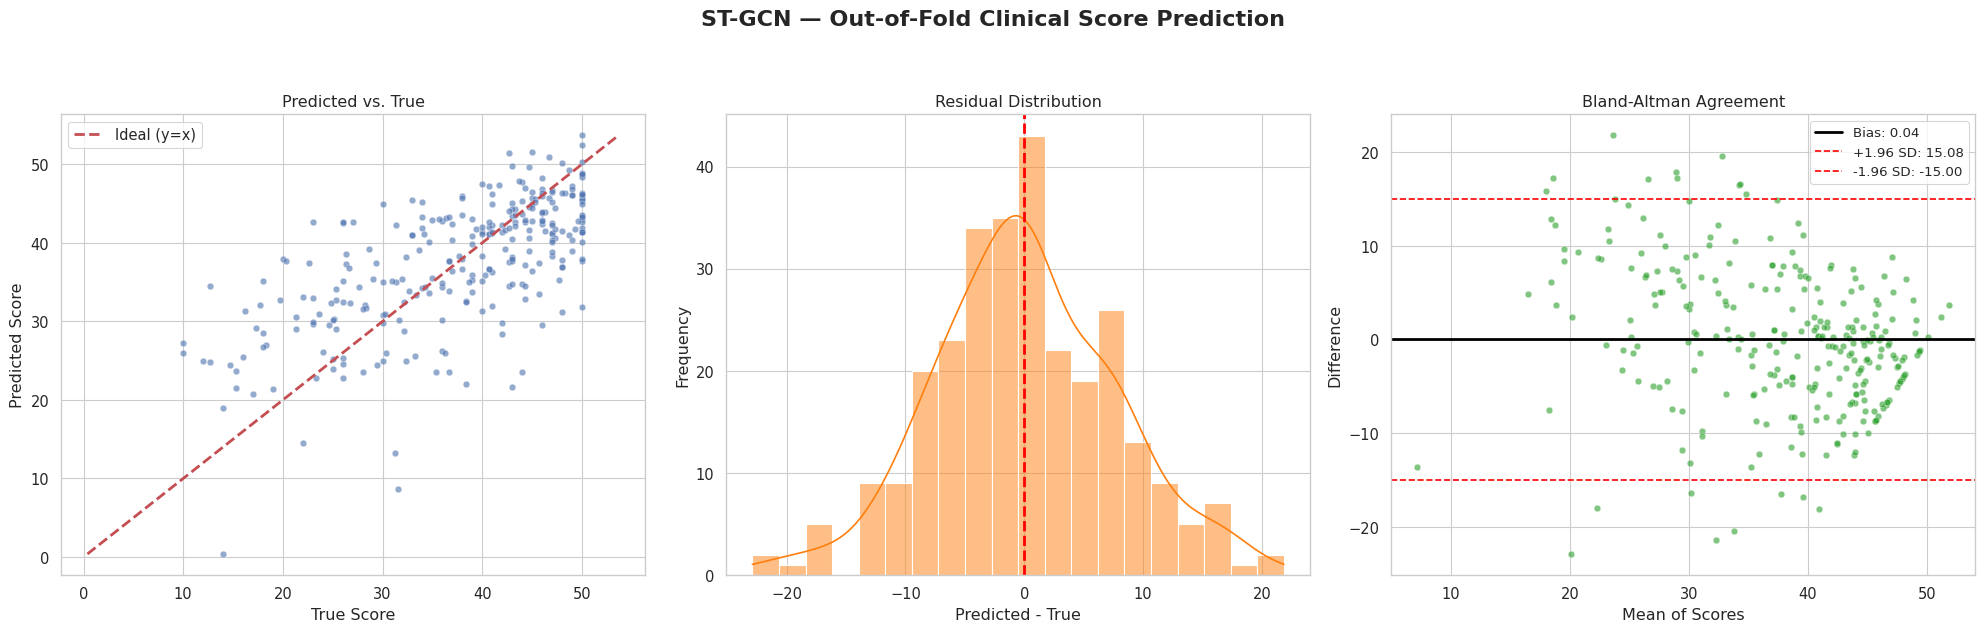

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

errors = oof_pred - oof_true
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("ST-GCN — Out-of-Fold Clinical Score Prediction", fontsize=16, fontweight='bold', y=1.05)

ax = axes[0]
sns.scatterplot(x=oof_true, y=oof_pred, alpha=0.6, ax=ax)
lo, hi = min(oof_true.min(), oof_pred.min()), max(oof_true.max(), oof_pred.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal (y=x)')
ax.set(title="Predicted vs. True", xlabel="True Score", ylabel="Predicted Score"); ax.legend()

ax = axes[1]
sns.histplot(errors, kde=True, bins=20, ax=ax, color='#ff7f0e')
ax.axvline(0, color='red', ls='--', lw=2)
ax.set(title="Residual Distribution", xlabel="Predicted - True", ylabel="Frequency")

ax = axes[2]
means = (oof_pred + oof_true) / 2
mb, sb = errors.mean(), errors.std()
sns.scatterplot(x=means, y=errors, alpha=0.6, ax=ax, color='#2ca02c')
ax.axhline(mb, color='black', lw=2, label=f'Bias: {mb:.2f}')
ax.axhline(mb + 1.96*sb, color='red', ls='--', label=f'+1.96 SD: {mb+1.96*sb:.2f}')
ax.axhline(mb - 1.96*sb, color='red', ls='--', label=f'-1.96 SD: {mb-1.96*sb:.2f}')
ax.set(title="Bland-Altman Agreement", xlabel="Mean of Scores", ylabel="Difference"); ax.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.savefig("STGCN_Evaluation.pdf", dpi=300, bbox_inches='tight')
plt.savefig("STGCN_Evaluation.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download('STGCN_Evaluation.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>